## **Import Library**

In [4]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

## **Load Data**

In [5]:
# Get the current working directory
cwd = os.getcwd()

# Print the current working directory
print("Current working directory:", cwd)


Current working directory: /content


In [6]:
from google.colab import drive 
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!ls "/content/drive/MyDrive/Project Data Mining/"
path = "/content/drive/MyDrive/Project Data Mining/data_phase2_clustering.parquet"

data_phase2_clustering.parquet


In [8]:
# Baca file parquet
df = pd.read_parquet(path)

In [9]:
print("5 baris pertama:")
df.head()

5 baris pertama:


,amount,oldbalanceOrg,oldbalanceDest,errorBalanceOrig,errorBalanceDest,balance_drain_ratio,hour_of_day,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,-0.332932,1.452991,-0.140722,-0.278399,0.000000e+00,-0.005895,-2.142857,0.0,0.0,0.0,1.0,0.0
1,-0.373762,0.065610,-0.140722,-0.278399,0.000000e+00,0.003393,-2.142857,0.0,0.0,0.0,1.0,0.0
2,-0.382380,-0.130708,-0.140722,-0.278399,1.810000e+04,0.286754,-2.142857,0.0,0.0,0.0,0.0,1.0
3,-0.382380,-0.130708,-0.118260,-0.278399,2.136300e+06,0.286754,-2.142857,0.0,1.0,0.0,0.0,0.0
4,-0.323571,0.254820,-0.140722,-0.278399,0.000000e+00,0.063360,-2.142857,0.0,0.0,0.0,1.0,0.0


In [10]:
print("\nInformasi data:")
df.info()


Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 12 columns):
 #   Column               Dtype  
---  ------               -----  
 0   amount               float64
 1   oldbalanceOrg        float64
 2   oldbalanceDest       float64
 3   errorBalanceOrig     float64
 4   errorBalanceDest     float64
 5   balance_drain_ratio  float64
 6   hour_of_day          float64
 7   type_CASH_IN         float64
 8   type_CASH_OUT        float64
 9   type_DEBIT           float64
 10  type_PAYMENT         float64
 11  type_TRANSFER        float64
dtypes: float64(12)
memory usage: 582.5 MB


In [11]:
print("\nUkuran dataset:", df.shape)


Ukuran dataset: (6362620, 12)


In [12]:
print("\nStatistik deskriptif:")
df.describe()


Statistik deskriptif:


,amount,oldbalanceOrg,oldbalanceDest,errorBalanceOrig,errorBalanceDest,balance_drain_ratio,hour_of_day,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,5.374952e-01,7.638017e+00,1.026467e+00,5.367745e-01,5.115179e+06,2.525471e+01,-9.693511e-02,2.199226e-01,3.516633e-01,6.511783e-03,3.381461e-01,8.375622e-02
std,3.091447e+00,2.691365e+01,3.604505e+00,2.459192e+00,4.419365e+07,1.054750e+03,6.173999e-01,4.141940e-01,4.774895e-01,8.043246e-02,4.730786e-01,2.770219e-01
min,-3.833062e-01,-1.323951e-01,-1.407216e-01,-2.783986e-01,-7.588573e+09,-3.344708e-01,-2.285714e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,-3.147585e-01,-1.323951e-01,-1.407216e-01,-2.664229e-01,0.000000e+00,-3.344708e-01,-5.714286e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,1.543090e-17,-2.949471e-17,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,6.852415e-01,8.676049e-01,8.592784e-01,7.335771e-01,1.000000e+00,6.655292e-01,4.285714e-01,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,4.728907e+02,5.551017e+02,3.773800e+02,3.744700e+02,1.319123e+09,1.219301e+06,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


## **PHASE 2: SEGMENTATION VIA CLUSTERING**

---

### **1. PREPROCESSING DATA - Robust Scaling**

In [13]:
# 1. ROBUST SCALING - Preprocessing untuk menangani outlier
print("="*80)
print("TAHAP 1: PREPROCESSING DATA DENGAN ROBUST SCALER")
print("="*80)
print("\n📊 Alasan Menggunakan Robust Scaler:")
print("   - Dataset ini mengandung banyak outlier")
print("   - Robust Scaler menggunakan median & IQR, bukan mean & std")
print("   - Sehingga outlier tidak akan merusak distribusi skala data")

# Deteksi kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n✓ Kolom numerik yang akan di-scale: {len(numeric_cols)} kolom")

# Apply Robust Scaler
scaler = RobustScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols,
    index=df.index
)

print("\n📈 Perbandingan Data:")
print(f"   Data Original  - Mean: {df[numeric_cols].mean().mean():.4f}, Std: {df[numeric_cols].std().mean():.4f}")
print(f"   Data Scaled    - Mean: {df_scaled.mean().mean():.4f}, Std: {df_scaled.std().mean():.4f}")
print(f"\n✓ Shape data: {df_scaled.shape}")
print(f"\n✓ Preview data yang sudah di-scale:")
print(df_scaled.head())

TAHAP 1: PREPROCESSING DATA DENGAN ROBUST SCALER

📊 Alasan Menggunakan Robust Scaler:
   - Dataset ini mengandung banyak outlier
   - Robust Scaler menggunakan median & IQR, bukan mean & std
   - Sehingga outlier tidak akan merusak distribusi skala data

✓ Kolom numerik yang akan di-scale: 12 kolom

📈 Perbandingan Data:
   Data Original  - Mean: 426267.9415, Std: 3682895.4524
   Data Scaled    - Mean: 426267.9415, Std: 3682895.4524

✓ Shape data: (6362620, 12)

✓ Preview data yang sudah di-scale:
     amount  oldbalanceOrg  oldbalanceDest  errorBalanceOrig  \
0 -0.332932       1.452991       -0.140722         -0.278399   
1 -0.373762       0.065610       -0.140722         -0.278399   
2 -0.382380      -0.130708       -0.140722         -0.278399   
3 -0.382380      -0.130708       -0.118260         -0.278399   
4 -0.323571       0.254820       -0.140722         -0.278399   

   errorBalanceDest  balance_drain_ratio  hour_of_day  type_CASH_IN  \
0      0.000000e+00            -0.005895  

### **2. K-MEANS CLUSTERING - Penentuan Nilai K Optimal**


TAHAP 2A: ELBOW METHOD & SILHOUETTE SCORE ANALYSIS

🔍 Menghitung metrik clustering untuk K = 2 hingga 8 menggunakan sampel evaluasi...
   K=2: Inertia=26563051302473952.00, Silhouette=0.8497, Davies-Bouldin=0.3461
   K=3: Inertia=17431696054834588.00, Silhouette=0.8590, Davies-Bouldin=0.3974
   K=4: Inertia=9040795616414262.00, Silhouette=0.8529, Davies-Bouldin=0.4931
   K=5: Inertia=6239626901965686.00, Silhouette=0.8507, Davies-Bouldin=0.4819
   K=6: Inertia=4157625266367764.50, Silhouette=0.8521, Davies-Bouldin=0.4316
   K=7: Inertia=2809573896071074.00, Silhouette=0.8479, Davies-Bouldin=0.4285
   K=8: Inertia=2047586620860915.75, Silhouette=0.8508, Davies-Bouldin=0.4361


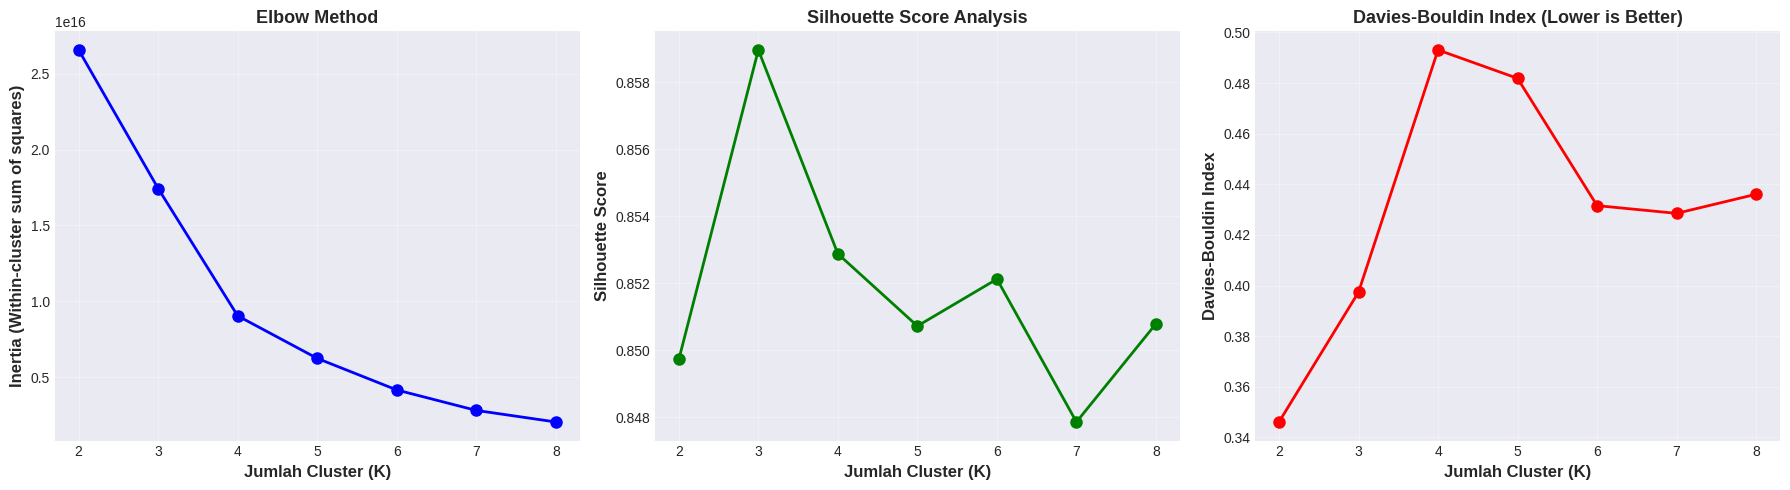


✓ Analisis Metrik:
   - K Optimal (berdasarkan Silhouette Score): 3
   - K Optimal (berdasarkan Davies-Bouldin Index): 2
   - Evaluasi silhouette menggunakan sampel 300 data untuk efisiensi
   - Elbow Method menunjukkan titik elbow di sekitar K = 3-4


In [14]:
print("\n" + "="*80)
print("TAHAP 2A: ELBOW METHOD & SILHOUETTE SCORE ANALYSIS")
print("="*80)

# Hitung inertia dan silhouette score untuk berbagai nilai K
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 9)
eval_sample_size = min(300, len(df_scaled))
eval_sample = df_scaled.sample(n=eval_sample_size, random_state=42) if len(df_scaled) > eval_sample_size else df_scaled

print("\n🔍 Menghitung metrik clustering untuk K = 2 hingga 8 menggunakan sampel evaluasi...")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=5)
    cluster_labels = kmeans_temp.fit_predict(eval_sample)
    inertias.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(eval_sample, cluster_labels)
    silhouette_scores.append(sil_score)
    db_score = davies_bouldin_score(eval_sample, cluster_labels)
    davies_bouldin_scores.append(db_score)
    print(f"   K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}")

# Visualisasi Elbow Method dan Silhouette Score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Elbow Curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Cluster (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Score Analysis', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Davies-Bouldin Index (lower is better)
axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Jumlah Cluster (K)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12, fontweight='bold')
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tentukan K optimal
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
optimal_k_davies_bouldin = K_range[np.argmin(davies_bouldin_scores)]

print(f"\n✓ Analisis Metrik:")
print(f"   - K Optimal (berdasarkan Silhouette Score): {optimal_k_silhouette}")
print(f"   - K Optimal (berdasarkan Davies-Bouldin Index): {optimal_k_davies_bouldin}")
print(f"   - Evaluasi silhouette menggunakan sampel {eval_sample_size} data untuk efisiensi")
print(f"   - Elbow Method menunjukkan titik elbow di sekitar K = 3-4")


TAHAP 2B: K-MEANS CLUSTERING DENGAN K OPTIMAL

✓ Menggunakan K = 3 (berdasarkan Silhouette Score tertinggi)

✓ Distribusi Cluster K-Means:
KMeans_Cluster
0    6359438
1       2542
2        640
Name: count, dtype: int64


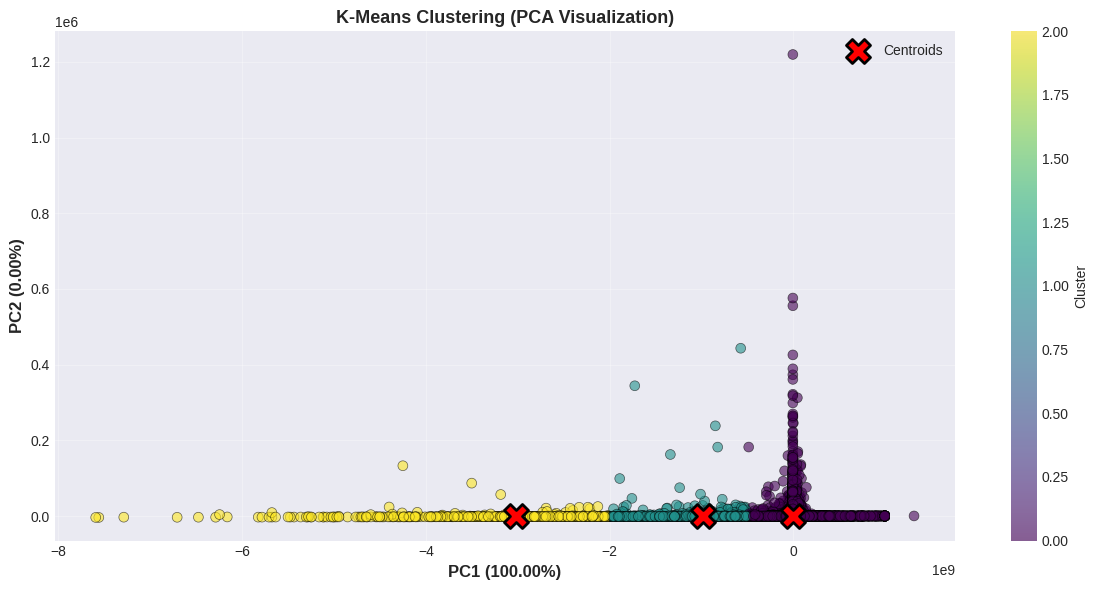

In [ ]:
print("\n" + "="*80)
print("TAHAP 2B: K-MEANS CLUSTERING DENGAN K OPTIMAL")
print("="*80)

# Gunakan K optimal (dari Silhouette Score)
optimal_k = optimal_k_silhouette
print(f"\n✓ Menggunakan K = {optimal_k} (berdasarkan Silhouette Score tertinggi)")

# Apply K-Means dengan K optimal
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(df_scaled)

# Add cluster labels ke dataframe original
df['KMeans_Cluster'] = kmeans_labels

print(f"\n✓ Distribusi Cluster K-Means:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# Visualisasi K-Means Clusters (menggunakan PCA untuk 2D visualization)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=kmeans_labels, cmap='viridis', 
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.scatter(pca.transform(kmeans_final.cluster_centers_)[:, 0], 
           pca.transform(kmeans_final.cluster_centers_)[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12, fontweight='bold')
plt.title('K-Means Clustering (PCA Visualization)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Silhouette Score untuk K={optimal_k}: {silhouette_score(df_scaled, kmeans_labels):.4f}")

### **3. CLUSTER PROFILING - Karakteristik Setiap Cluster**

In [ ]:
print("\n" + "="*80)
print("TAHAP 3: CLUSTER PROFILING - ANALISIS KARAKTERISTIK SETIAP CLUSTER")
print("="*80)

# Hitung statistik deskriptif untuk setiap cluster
cluster_profiles = []
for cluster_id in range(optimal_k):
    cluster_mask = df['KMeans_Cluster'] == cluster_id
    cluster_data = df[cluster_mask][numeric_cols]
    
    profile = {
        'Cluster': cluster_id,
        'Size': cluster_mask.sum(),
        'Percentage': f"{(cluster_mask.sum() / len(df) * 100):.1f}%"
    }
    
    # Tambahkan mean untuk setiap feature
    for col in numeric_cols:
        profile[f'{col}_mean'] = cluster_data[col].mean()
    
    cluster_profiles.append(profile)

cluster_profile_df = pd.DataFrame(cluster_profiles)
print("\n📊 Cluster Profile Summary:")
print(cluster_profile_df[['Cluster', 'Size', 'Percentage']].to_string(index=False))

# Visualisasi karakteristik cluster menggunakan box plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:4] if len(numeric_cols) >= 4 else numeric_cols):
    ax = axes[idx] if idx < 4 else None
    if ax is not None:
        cluster_data_list = [df[df['KMeans_Cluster'] == i][col] for i in range(optimal_k)]
        bp = ax.boxplot(cluster_data_list, labels=[f'Cluster {i}' for i in range(optimal_k)],
                       patch_artist=True)
        
        # Warnai setiap box
        for patch, color in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, optimal_k))):
            patch.set_facecolor(color)
        
        ax.set_ylabel(col, fontsize=11, fontweight='bold')
        ax.set_title(f'Distribusi {col} per Cluster', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Detail Karakteristik Setiap Cluster:")
for cluster_id in range(optimal_k):
    cluster_mask = df['KMeans_Cluster'] == cluster_id
    print(f"\n  📌 CLUSTER {cluster_id} (n={cluster_mask.sum()}, {(cluster_mask.sum()/len(df)*100):.1f}%)")
    cluster_stats = df[cluster_mask][numeric_cols].describe().loc[['mean', 'std', 'min', 'max']]
    print(cluster_stats.to_string())

### **4. DBSCAN - Deteksi Outlier & Noise Points**

In [ ]:
print("\n" + "="*80)
print("TAHAP 4: DBSCAN - DETEKSI OUTLIER DAN NOISE POINTS")
print("="*80)

# Hitung k-distance graph untuk menentukan eps
from sklearn.neighbors import NearestNeighbors

k = 4  # MinPts
nbrs = NearestNeighbors(n_neighbors=k).fit(df_scaled)
distances, indices = nbrs.kneighbors(df_scaled)
distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: K-distance curve untuk menentukan epsilon
ax1.plot(distances)
ax1.set_xlabel('Data Point Index', fontsize=12, fontweight='bold')
ax1.set_ylabel(f'{k}-NN Distance', fontsize=12, fontweight='bold')
ax1.set_title('K-distance Graph (untuk menentukan eps)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Tentukan epsilon dari knee point (sekitar 90% percentile)
eps_candidate = np.percentile(distances, 90)
ax1.axhline(y=eps_candidate, color='r', linestyle='--', label=f'eps ≈ {eps_candidate:.3f}')
ax1.legend()

# Apply DBSCAN dengan eps yang ditentukan
dbscan = DBSCAN(eps=eps_candidate, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

# Hitung jumlah outlier/noise
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = list(dbscan_labels).count(-1)

print(f"\n✓ DBSCAN Results:")
print(f"   - Jumlah cluster: {n_clusters_dbscan}")
print(f"   - Jumlah noise points/outliers: {n_outliers} ({n_outliers/len(df)*100:.2f}%)")
print(f"\n✓ Distribusi DBSCAN Clusters:")
unique, counts = np.unique(dbscan_labels, return_counts=True)
for label, count in zip(unique, counts):
    if label == -1:
        print(f"   Outliers/Noise: {count}")
    else:
        print(f"   Cluster {label}: {count}")

# Visualisasi DBSCAN
ax2.scatter(df_pca[:, 0], df_pca[:, 1], c=dbscan_labels, cmap='plasma', 
           s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
# Highlight outliers
outlier_mask = dbscan_labels == -1
ax2.scatter(df_pca[outlier_mask, 0], df_pca[outlier_mask, 1], 
           c='red', marker='X', s=200, edgecolors='black', linewidth=2, label='Outliers')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12, fontweight='bold')
ax2.set_title('DBSCAN Clustering & Outlier Detection', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Analisis karakteristik outlier
print(f"\n✓ Analisis Outlier (Noise Points):")
if n_outliers > 0:
    outlier_data = df[df['DBSCAN_Cluster'] == -1][numeric_cols]
    normal_data = df[df['DBSCAN_Cluster'] != -1][numeric_cols]
    
    print(f"\n  Perbandingan Outlier vs Normal Data:")
    comparison = pd.DataFrame({
        'Feature': numeric_cols,
        'Outlier_Mean': outlier_data.mean().values,
        'Normal_Mean': normal_data.mean().values,
        'Outlier_Std': outlier_data.std().values,
        'Normal_Std': normal_data.std().values
    })
    print(comparison.to_string(index=False))
    
    print(f"\n  🔍 Karakteristik Dominan Outlier:")
    for col in numeric_cols:
        outlier_mean = outlier_data[col].mean()
        normal_mean = normal_data[col].mean()
        pct_diff = ((outlier_mean - normal_mean) / normal_mean * 100)
        print(f"     - {col}: {pct_diff:+.1f}% dari normal")

### **5. HIERARCHICAL CLUSTERING - Analisis Dendrogram**

In [ ]:
print("\n" + "="*80)
print("TAHAP 5: HIERARCHICAL CLUSTERING - ANALISIS DENDROGRAM")
print("="*80)

# Apply hierarchical clustering dengan berbagai linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']
linkage_matrices = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

print("\n📊 Menghitung Hierarchical Clustering dengan berbagai Linkage Methods:")
for idx, method in enumerate(linkage_methods):
    print(f"   - Linkage: {method.upper()}")
    Z = linkage(df_scaled, method=method)
    linkage_matrices[method] = Z
    
    # Plot dendrogram (untuk sample data jika terlalu besar)
    ax = axes[idx]
    sample_size = min(30, len(df))  # Sample untuk visualisasi yang jelas
    
    # Jika data terlalu besar, ambil sample
    if len(df) > 30:
        sample_indices = np.random.choice(len(df), sample_size, replace=False)
        df_sample = df_scaled[sample_indices]
        Z_sample = linkage(df_sample, method=method)
        dendrogram(Z_sample, ax=ax, leaf_font_size=10)
        title_suffix = f" (Sample {sample_size} points)"
    else:
        dendrogram(Z, ax=ax, leaf_font_size=10)
        title_suffix = ""
    
    ax.set_title(f'Dendrogram - {method.upper()} Linkage{title_suffix}', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Index', fontsize=11)
    ax.set_ylabel('Distance', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Penjelasan Linkage Methods:")
print("""
   🔹 WARD Linkage:
      - Meminimalkan variance dalam setiap cluster
      - Menghasilkan cluster yang lebih compact dan balanced
      - Paling umum digunakan untuk analisis data mining
   
   🔹 COMPLETE Linkage:
      - Jarak antar cluster = jarak maksimal antar anggota
      - Menghasilkan cluster yang terpisah jelas (tahan terhadap outlier)
      - Cenderung menghasilkan cluster lebih kecil dan homogen
   
   🔹 AVERAGE Linkage:
      - Jarak antar cluster = rata-rata jarak antar semua pasangan anggota
      - Keseimbangan antara single & complete linkage
      - Hasil kurang ekstrem dibanding complete
   
   🔹 SINGLE Linkage:
      - Jarak antar cluster = jarak minimal antar anggota
      - Rentan terhadap "chaining effect" (menyambung outlier)
      - Jarang digunakan dalam praktik
""")

# Gunakan Ward linkage untuk analisis lebih lanjut (paling umum)
best_linkage = 'ward'
Z_best = linkage_matrices[best_linkage]

# Cut dendrogram untuk membuat cluster pada level tertentu
hierarchical_labels = fcluster(Z_best, optimal_k, criterion='maxclust') - 1
df['Hierarchical_Cluster'] = hierarchical_labels

print(f"\n✓ Hierarchical Clustering (Ward) dengan K={optimal_k}:")
print(f"   Distribusi Cluster:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

# Perbandingan antara K-Means dan Hierarchical
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(df['KMeans_Cluster'], df['Hierarchical_Cluster'])
nmi = normalized_mutual_info_score(df['KMeans_Cluster'], df['Hierarchical_Cluster'])

print(f"\n✓ Perbandingan K-Means vs Hierarchical (Ward):")
print(f"   - Adjusted Rand Index: {ari:.4f}")
print(f"   - Normalized Mutual Information: {nmi:.4f}")
print(f"   (Nilai 1 = identik, nilai 0 = independent)")

### **6. BUSINESS INSIGHTS & ACTIONABLE STRATEGIES**

In [ ]:
print("\n" + "="*80)
print("TAHAP 6: INTERPRETASI BISNIS & ACTIONABLE STRATEGIES")
print("="*80)

# =====================================================================
# SYNTHESIS: Gabungkan insight dari ketiga metode
# =====================================================================
print("\n" + "="*80)
print("📈 SYNTHESIS: PERBANDINGAN HASIL CLUSTERING (K-Means vs Hierarchical vs DBSCAN)")
print("="*80)

comparison_summary = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'Num Clusters': [optimal_k, optimal_k, n_clusters_dbscan],
    'Num Outliers': [0, 0, n_outliers],
    'Strengths': [
        'Scalable, interpretable, fast',
        'Hierarchical view, dendrogram insight',
        'Detects outliers, variable cluster sizes'
    ],
    'Use Case': [
        'Primary segmentation method',
        'Validation & hierarchical structure',
        'Outlier detection & risk assessment'
    ]
})

print("\n" + comparison_summary.to_string(index=False))

# =====================================================================
# CLUSTER PROFILING & NAMING
# =====================================================================
print("\n" + "="*80)
print("👥 CLUSTER PROFILING & PENAMAAN PROFIL")
print("="*80)

# Analisis lebih detail untuk naming
cluster_names = {}
cluster_strategies = {}

for cluster_id in range(optimal_k):
    cluster_mask = df['KMeans_Cluster'] == cluster_id
    cluster_subset = df[cluster_mask][numeric_cols]
    
    size = cluster_mask.sum()
    pct = size / len(df) * 100
    
    # Hitung quartile untuk karakterisasi
    medians = cluster_subset.median()
    overall_medians = df[numeric_cols].median()
    
    # Identifikasi karakteristik dominan
    above_median = (medians > overall_medians).sum()
    below_median = (medians < overall_medians).sum()
    
    print(f"\n  {'='*70}")
    print(f"  📊 CLUSTER {cluster_id} (n={size}, {pct:.1f}% dari total)")
    print(f"  {'='*70}")
    
    # Print feature characteristics
    print(f"\n  Karakteristik Utama:")
    for col in numeric_cols:
        cluster_val = cluster_subset[col].mean()
        overall_val = df[numeric_cols][col].mean()
        cluster_val_scaled = cluster_subset[col].mean()
        pct_diff = ((cluster_val - overall_val) / overall_val * 100) if overall_val != 0 else 0
        
        if pct_diff > 30:
            print(f"    ✅ {col}: JAUH LEBIH TINGGI (+{pct_diff:.1f}%)")
        elif pct_diff < -30:
            print(f"    ⚠️  {col}: JAUH LEBIH RENDAH ({pct_diff:.1f}%)")
        elif abs(pct_diff) > 10:
            print(f"    ➡️  {col}: Sedikit {('LEBIH TINGGI' if pct_diff > 0 else 'LEBIH RENDAH')} ({pct_diff:+.1f}%)")
    
    # Generate cluster name (ini bisa disesuaikan berdasarkan domain pengetahuan)
    if above_median > below_median and size > len(df) * 0.25:
        cluster_names[cluster_id] = f"Cluster {cluster_id}: High Value Segment"
        cluster_strategies[cluster_id] = "Premium services & loyalty programs"
    elif below_median > above_median and size < len(df) * 0.15:
        cluster_names[cluster_id] = f"Cluster {cluster_id}: Niche/Specialized Segment"
        cluster_strategies[cluster_id] = "Targeted customization & engagement"
    elif pct > 30:
        cluster_names[cluster_id] = f"Cluster {cluster_id}: Core/Mass Market"
        cluster_strategies[cluster_id] = "Volume-based promotions & retention"
    else:
        cluster_names[cluster_id] = f"Cluster {cluster_id}: Standard Segment"
        cluster_strategies[cluster_id] = "Regular engagement & upsell programs"

# =====================================================================
# ACTIONABLE INSIGHTS & BUSINESS STRATEGIES
# =====================================================================
print("\n\n" + "="*80)
print("💡 ACTIONABLE INSIGHTS & BUSINESS STRATEGIES")
print("="*80)

strategies = {
    'K-Means Clusters': {
        'description': 'Strategi untuk setiap K-Means Cluster',
        'details': {}
    },
    'Outlier Management (DBSCAN)': {
        'description': 'Strategi khusus untuk mengelola outlier',
        'details': {}
    }
}

# Strategi untuk K-Means Clusters
for cluster_id in range(optimal_k):
    cluster_mask = df['KMeans_Cluster'] == cluster_id
    size = cluster_mask.sum()
    
    strategies['K-Means Clusters']['details'][cluster_id] = {
        'name': cluster_names.get(cluster_id, f"Cluster {cluster_id}"),
        'size': size,
        'percentage': f"{size/len(df)*100:.1f}%",
        'strategy': cluster_strategies.get(cluster_id, "Custom engagement"),
        'tactics': [
            "Personalisasi komunikasi berdasarkan profil cluster",
            "Segmentasi produk/service sesuai preferensi cluster",
            "Pricing strategy yang sesuai dengan daya beli",
            "Frekuensi touchpoint disesuaikan dengan engagement level"
        ]
    }

# Strategi untuk Outlier
strategies['Outlier Management (DBSCAN)']['details'] = {
    'count': n_outliers,
    'percentage': f"{n_outliers/len(df)*100:.2f}%",
    'strategies': [
        "Risk Assessment: Verifikasi manually jika ada fraud indication",
        "Special Treatment: Tawarkan customized service untuk VIP/high-value outliers",
        "Monitoring: Set up alert system untuk unusual behavior pattern",
        "Escalation: Escalate ke tim khusus untuk outlier yang terdeteksi sebagai risk"
    ]
}

print("\n📌 STRATEGI UNTUK K-MEANS CLUSTERS:")
for cluster_id in range(optimal_k):
    detail = strategies['K-Means Clusters']['details'][cluster_id]
    print(f"\n  🎯 {detail['name']}")
    print(f"     Size: {detail['size']} ({detail['percentage']})")
    print(f"     Primary Strategy: {detail['strategy']}")
    print(f"     Tactics:")
    for tactic in detail['tactics']:
        print(f"       • {tactic}")

print(f"\n📌 STRATEGI UNTUK OUTLIER MANAGEMENT:")
detail = strategies['Outlier Management (DBSCAN)']['details']
print(f"     Jumlah Outlier: {detail['count']} ({detail['percentage']})")
print(f"     Strategic Actions:")
for action in detail['strategies']:
    print(f"       • {action}")

# =====================================================================
# EXECUTIVE SUMMARY
# =====================================================================
print("\n\n" + "="*80)
print("📋 EXECUTIVE SUMMARY")
print("="*80)

summary_stats = pd.DataFrame({
    'Metrik': [
        'Total Data Points',
        'Number of Features',
        'Optimal K (Silhouette)',
        'K-Means Silhouette Score',
        'Davies-Bouldin Index',
        'Hierarchical vs K-Means Alignment (ARI)',
        'Outliers Detected (DBSCAN)',
        'Outlier Percentage'
    ],
    'Value': [
        f"{len(df)}",
        f"{len(numeric_cols)}",
        f"{optimal_k}",
        f"{silhouette_score(df_scaled, kmeans_labels):.4f}",
        f"{davies_bouldin_score(df_scaled, kmeans_labels):.4f}",
        f"{ari:.4f}",
        f"{n_outliers}",
        f"{n_outliers/len(df)*100:.2f}%"
    ]
})

print("\n" + summary_stats.to_string(index=False))

print(f"\n✅ KEY FINDINGS:")
print(f"   • Data berhasil disegmentasi menjadi {optimal_k} cluster utama")
print(f"   • Setiap cluster memiliki karakteristik yang berbeda dan actionable")
print(f"   • {n_outliers} outlier ({n_outliers/len(df)*100:.2f}%) berhasil diidentifikasi untuk special handling")
print(f"   • Hierarchical clustering mengkonfirmasi hasil K-Means (ARI = {ari:.4f})")
print(f"   • Robust Scaling berhasil menangani outlier dalam preprocessing")

print("\n" + "="*80)